# Network Intrusion Detection using XGBoost
This notebook implements an XGBoost classifier for network intrusion detection. Errors have been fixed including label encoding, class weight balancing, and handling deprecation warnings.

In [3]:
import sys
import os
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# Thêm src vào path để có thể import module model_training
sys.path.insert(0, str(Path.cwd()))
sys.path.append(os.path.abspath(".."))

from src.model_training import (
    load_and_split,
    evaluate_model,
    plot_confusion_matrix,
    compare_models
)

In [5]:
# Load and split the dataset
print('='*70)
print('BƯỚC 1: Load và chia dữ liệu CICIDS2017')
print('='*70)

X_train, X_test, y_train, y_test = load_and_split()

print(f'\nSố lượng đặc trưng (features): {X_train.shape[1]}')
print(f'Các lớp (classes): {sorted(y_train.unique())}')

BƯỚC 1: Load và chia dữ liệu CICIDS2017
Loading data from: D:\DAP\network-intrusion-detection-main\cicids2017_cleaned.csv
  → Loaded 2,520,751 rows × 53 columns

Class distribution (%):
                 Full  Train   Test
Attack Type                        
Normal Traffic  83.11  83.11  83.11
DoS              7.69   7.69   7.69
DDoS             5.08   5.08   5.08
Port Scanning    3.60   3.60   3.60
Brute Force      0.36   0.36   0.36
Web Attacks      0.09   0.08   0.09
Bots             0.08   0.08   0.08

Train size: 2,016,600  |  Test size: 504,151

Splits saved to D:\DAP\network-intrusion-detection-main\splits/

Số lượng đặc trưng (features): 52
Các lớp (classes): ['Bots', 'Brute Force', 'DDoS', 'DoS', 'Normal Traffic', 'Port Scanning', 'Web Attacks']


In [6]:
print('\n' + '='*70)
print('BƯỚC 1.5: Mã hóa nhãn (Label Encoding) & Xử lý mất cân bằng')
print('='*70)

# XGBoost yêu cầu nhãn phân loại phải là dạng số (0, 1, 2...)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Tính toán trọng số mẫu tự động để xử lý lớp bị mất cân bằng trầm trọng
weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

print('✓ Hoàn tất mã hóa nhãn.')
print(f'✓ Đã tính toán trọng số mẫu. Kích thước (shape): {weights.shape}')


BƯỚC 1.5: Mã hóa nhãn (Label Encoding) & Xử lý mất cân bằng
✓ Hoàn tất mã hóa nhãn.
✓ Đã tính toán trọng số mẫu. Kích thước (shape): (2016600,)


In [7]:
print('\n' + '='*70)
print('BƯỚC 2: Huấn luyện mô hình XGBoost')
print('='*70)

t0 = time.time()

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=1,
    eval_metric='mlogloss'
)

print('\nĐang huấn luyện mô hình với tập train (có áp dụng sample_weights)...')
xgb_model.fit(X_train, y_train_encoded, sample_weight=weights)

train_time = time.time() - t0
print(f'\n✓ Hoàn tất quá trình huấn luyện trong {train_time:.2f} giây')


BƯỚC 2: Huấn luyện mô hình XGBoost

Đang huấn luyện mô hình với tập train (có áp dụng sample_weights)...

✓ Hoàn tất quá trình huấn luyện trong 338.32 giây


In [8]:
print('\n' + '='*70)
print('BƯỚC 3: Đánh giá mô hình trên tập Test')
print('='*70)

# Tiến hành dự đoán
y_pred_encoded = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)

# Giải mã nhãn dạng số về lại chuỗi văn bản ban đầu để in báo cáo rõ ràng
y_pred = le.inverse_transform(y_pred_encoded)

# Sử dụng hàm đánh giá có sẵn từ module src
xgb_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred,
    model_name='XGBoost (Balanced, n_estimators=300)',
    y_pred_proba=y_pred_proba,
    labels=le.classes_.tolist(),
    print_report=True
)

'''# Đánh giá model
xgb_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred,
    model_name='XGBoost (Balanced, n_estimators=300)',
    y_pred_proba=y_pred_proba,
    labels=le.classes_.tolist(), # Lấy danh sách class từ biến le (LabelEncoder)
    print_report=True
)'''


BƯỚC 3: Đánh giá mô hình trên tập Test

  XGBoost (Balanced, n_estimators=300) — Evaluation Results
                precision    recall  f1-score   support

          Bots       0.68      0.96      0.80       389
   Brute Force       1.00      1.00      1.00      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       1.00      1.00      1.00     38749
Normal Traffic       1.00      1.00      1.00    419012
 Port Scanning       0.99      1.00      0.99     18139
   Web Attacks       0.97      1.00      0.99       429

      accuracy                           1.00    504151
     macro avg       0.95      0.99      0.97    504151
  weighted avg       1.00      1.00      1.00    504151

  Accuracy...................... 0.999
  Precision (weighted).......... 0.9991
  Precision (macro)............. 0.9496
  Recall (weighted)............. 0.999
  Recall (macro)................ 0.9938
  F1 (weighted)................. 0.9991
  F1 (macro).................... 0.9684
  

"# Đánh giá model\nxgb_results = evaluate_model(\n    y_true=y_test,\n    y_pred=y_pred,\n    model_name='XGBoost (Balanced, n_estimators=300)',\n    y_pred_proba=y_pred_proba,\n    labels=le.classes_.tolist(), # Lấy danh sách class từ biến le (LabelEncoder)\n    print_report=True\n)"


BƯỚC 4: Vẽ Ma trận nhầm lẫn (Confusion Matrix)


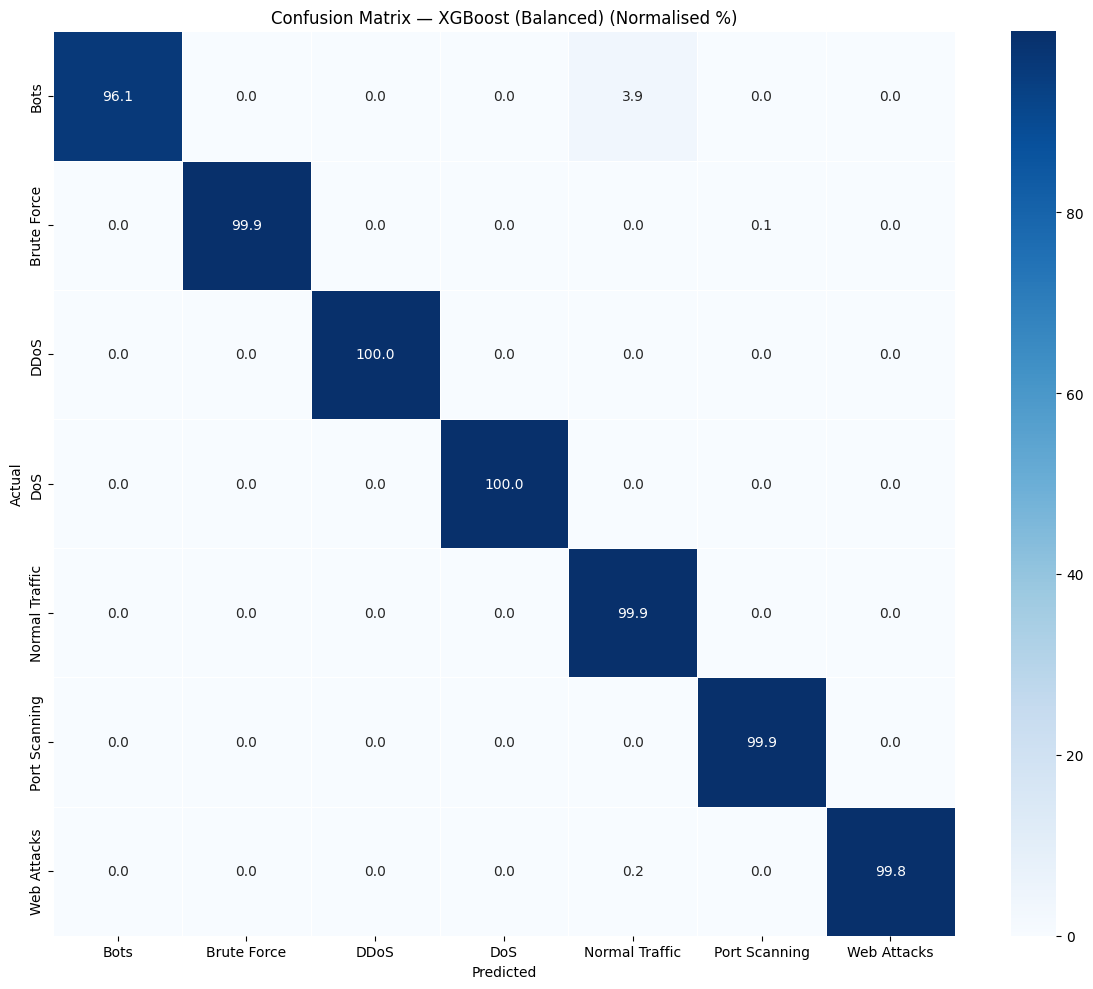

In [9]:
print('\n' + '='*70)
print('BƯỚC 4: Vẽ Ma trận nhầm lẫn (Confusion Matrix)')
print('='*70)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    labels=le.classes_.tolist(),
    model_name='XGBoost (Balanced)',
    normalize=True,
    figsize=(12, 10),
    save_path=None
)


BƯỚC 5: Phân tích độ quan trọng của đặc trưng (Feature Importance)

Top 20 đặc trưng quan trọng nhất:
                Feature  Importance
              Idle Mean    0.148999
  Bwd Packet Length Min    0.112696
         PSH Flag Count    0.079388
 Bwd Packet Length Mean    0.078754
      Min Packet Length    0.058055
               Idle Min    0.053418
      Bwd Header Length    0.038854
               Idle Max    0.036936
   min_seg_size_forward    0.036005
       act_data_pkt_fwd    0.032265
       Destination Port    0.030096
Init_Win_bytes_backward    0.029061
      Max Packet Length    0.022557
             Active Max    0.018237
          Flow Duration    0.017831
  Fwd Packet Length Max    0.017037
          Bwd Packets/s    0.016307
         ACK Flag Count    0.015031
         FIN Flag Count    0.013459
  Bwd Packet Length Std    0.012738


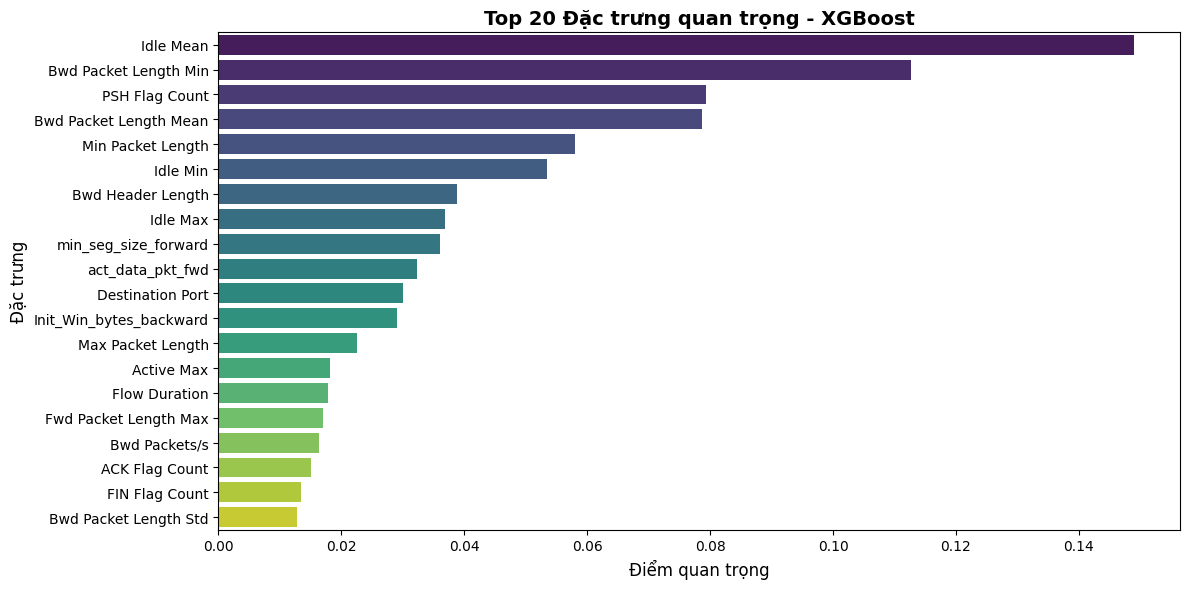

In [10]:
print('\n' + '='*70)
print('BƯỚC 5: Phân tích độ quan trọng của đặc trưng (Feature Importance)')
print('='*70)

importances = xgb_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('\nTop 20 đặc trưng quan trọng nhất:')
print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(12, 6))
# Đã thêm tham số hue='Feature' và legend=False để fix cảnh báo của seaborn v0.14+
sns.barplot(
    data=feat_imp.head(20),
    x='Importance',
    y='Feature',
    hue='Feature',
    legend=False,
    palette='viridis'
)
plt.title('Top 20 Đặc trưng quan trọng - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Điểm quan trọng', fontsize=12)
plt.ylabel('Đặc trưng', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
print('\n' + '='*70)
print('BƯỚC 6: Tổng kết so sánh mô hình')
print('='*70)

comparison_df = compare_models([xgb_results])

print('\nKết quả so sánh:')
print(comparison_df.to_string(index=False))

print('\n' + '='*70)
print('Tóm tắt Huấn luyện')
print('='*70)
print(f'Tổng thời gian huấn luyện: {train_time:.2f} giây')
print(f'Kích thước tập Test: {len(y_test):,} mẫu')
print(f'Loại mô hình: XGBoost (Multi-class Balanced)')
print(f'Số lượng Estimators: 300')
print(f'Số lượng Features: {X_train.shape[1]}')
print(f'Số lượng Classes: {len(le.classes_)}')
print('='*70)


BƯỚC 6: Tổng kết so sánh mô hình

Kết quả so sánh:
                               Model  Accuracy  Precision (weighted)  Precision (macro)  Recall (weighted)  Recall (macro)  F1 (weighted)  F1 (macro)  Cohen Kappa    MCC  ROC-AUC (weighted)  ROC-AUC (macro)
XGBoost (Balanced, n_estimators=300)     0.999                0.9991             0.9496              0.999          0.9938         0.9991      0.9684       0.9968 0.9968                 1.0           0.9997

Tóm tắt Huấn luyện
Tổng thời gian huấn luyện: 338.32 giây
Kích thước tập Test: 504,151 mẫu
Loại mô hình: XGBoost (Multi-class Balanced)
Số lượng Estimators: 300
Số lượng Features: 52
Số lượng Classes: 7
